⚽ Shot Analysis — World Cup 2018 Final

This project analyzes shot patterns using StatsBomb event data.

The goal is to:
- Understand shot locations
- Compare goals vs missed shots
- Analyze expected goals (xG)
- Evaluate player efficiency

In [25]:
!pip install statsbombpy pandas matplotlib seaborn
!pip install mplsoccer

In [26]:
from statsbombpy import sb
import pandas as pd
import matplotlib.pyplot as plt


## Data Loading

In [27]:
competitions = sb.competitions()
competitions.head()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882


## Data Cleaning

In [28]:
matches = sb.matches(competition_id=43, season_id=3)
matches.head()

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
0,7585,2018-07-03,20:00:00.000,1,1,available,scheduled,2023-07-24T13:06:27.791230,2021-06-13T16:17:31.694,4,...,Argentina,277,Gareth Southgate,None,1970-09-03,68,England,1.0.2,None,None
1,7570,2018-06-28,20:00:00.000,0,1,available,scheduled,2023-07-24T13:06:39.637575,2021-06-13T16:17:31.694,3,...,England,263,Roberto Martínez Montoliú,Roberto Martínez,1973-07-13,214,Spain,1.0.2,None,None
2,7586,2018-07-03,16:00:00.000,1,0,available,scheduled,2023-07-24T13:05:18.578795,2021-06-13T16:17:31.694,4,...,Sweden,492,Vladimir Petković,None,1963-08-15,28,Bosnia and Herzegovina,1.0.2,None,None
3,7557,2018-06-25,20:00:00.000,1,1,available,scheduled,2023-07-24T13:03:08.956903,2021-06-13T16:17:31.694,3,...,Portugal,607,Fernando Manuel Fernandes da Costa Santos,Fernando Santos,1954-10-10,183,Portugal,1.0.2,None,None
4,7542,2018-06-20,14:00:00.000,1,0,available,scheduled,2023-07-24T13:02:10.657273,2021-06-13T16:17:31.694,2,...,Portugal,642,Hervé Renard,None,1968-09-30,78,France,1.0.2,None,None


In [29]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   match_id                   64 non-null     int64 
 1   match_date                 64 non-null     object
 2   kick_off                   64 non-null     object
 3   home_score                 64 non-null     int64 
 4   away_score                 64 non-null     int64 
 5   match_status               64 non-null     object
 6   match_status_360           64 non-null     object
 7   last_updated               64 non-null     object
 8   last_updated_360           64 non-null     object
 9   match_week                 64 non-null     int64 
 10  competition_id             64 non-null     int64 
 11  competition_country_name   64 non-null     object
 12  competition_name           64 non-null     object
 13  competition                64 non-null     object
 14  season_id   

In [30]:
match = matches[(matches['home_team']=='France') & (matches['away_team']== 'Croatia')]
match.head()




,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
39,8658,2018-07-15,17:00:00.000,4,2,available,scheduled,2023-07-24T13:03:36.244040,2021-06-13T16:17:31.694,7,...,France,307,Zlatko Dalić,None,1966-10-26,56,Croatia,1.0.2,None,None


In [31]:
match_id = match['match_id'].values[0]


In [32]:
events = sb.events(match_id=match_id)
events.head()

,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,carry_end_location,clearance_aerial_won,counterpress,dribble_outcome,dribble_overrun,duel_outcome,duel_type,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 442, 'lineup': [{'player': {'id'...",France,771,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 433, 'lineup': [{'player': {'id'...",Croatia,785,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,France,771,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Croatia,785,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Croatia,785,00:00:00.000,Half Start,NaN


In [33]:
events[['type']].head(10) 


,type
0,Starting XI
1,Starting XI
2,Half Start
3,Half Start
4,Half Start
5,Half Start
6,Pass
7,Pass
8,Pass
9,Pass


In [34]:
shots = events[events['type'] == 'Shot'].copy()
len(shots)

23

In [35]:
shots['x'] = shots['location'].apply(lambda x: x[0])
shots['y'] = shots['location'].apply(lambda x: x[1]) 
shots.head()



,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,carry_end_location,clearance_aerial_won,counterpress,dribble_outcome,dribble_overrun,duel_outcome,duel_type,...,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,x,y
2906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Croatia,785,00:20:51.227,Shot,NaN,112.0,49.0
2907,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Croatia,785,00:23:34.907,Shot,NaN,108.0,29.0
2908,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Croatia,785,00:27:53.880,Shot,NaN,105.0,32.0
2909,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,France,771,00:37:56.787,Shot,NaN,108.0,40.0
2910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Croatia,785,00:39:25.267,Shot,NaN,108.0,41.0


## Shot Map Visualization

In [36]:
#Basic version (matplotlib)
#plt.figure(figsize=(10,7))
#plt.scatter(shots['x'],shots['y'],alpha=0.6)
#plt.title("Shot Map - France vs Croatia (World Cup 2018 Final)")
#plt.xlabel("Pitch Lenght")
#plt.ylabel("Pitch Width")
#plt.show()

In [37]:
goals = shots[shots['shot_outcome']=='Goal']
misses = shots[shots['shot_outcome']!= 'Goal']

In [38]:
#Basic version (matplotlib)

#plt.scatter(misses['x'], misses['y'], alpha=0.5, label="Misses")
#plt.scatter(goals['x'], goals['y'],s=100, edgecolor='black', label="Goals")
#plt.legend()
#plt.title("Goals vs Misses")
#plt.show()


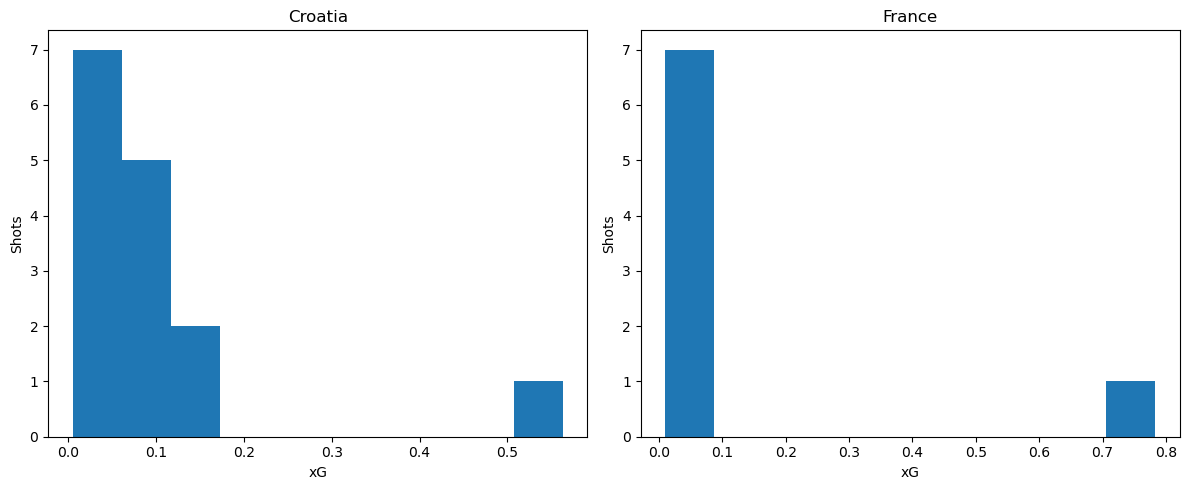

In [39]:
#xG Analysis

teams = shots['team'].unique()

fig, axes = plt.subplots(1, len(teams), figsize=(12,5))

for i, team in enumerate(teams):
    team_shots = shots[shots['team'] == team]
    
    axes[i].hist(team_shots['shot_statsbomb_xg'], bins=10)
    axes[i].set_title(team)
    axes[i].set_xlabel("xG")
    axes[i].set_ylabel("Shots")

plt.tight_layout()
plt.savefig("xg_subplots.png", dpi=300, bbox_inches='tight')
plt.show()


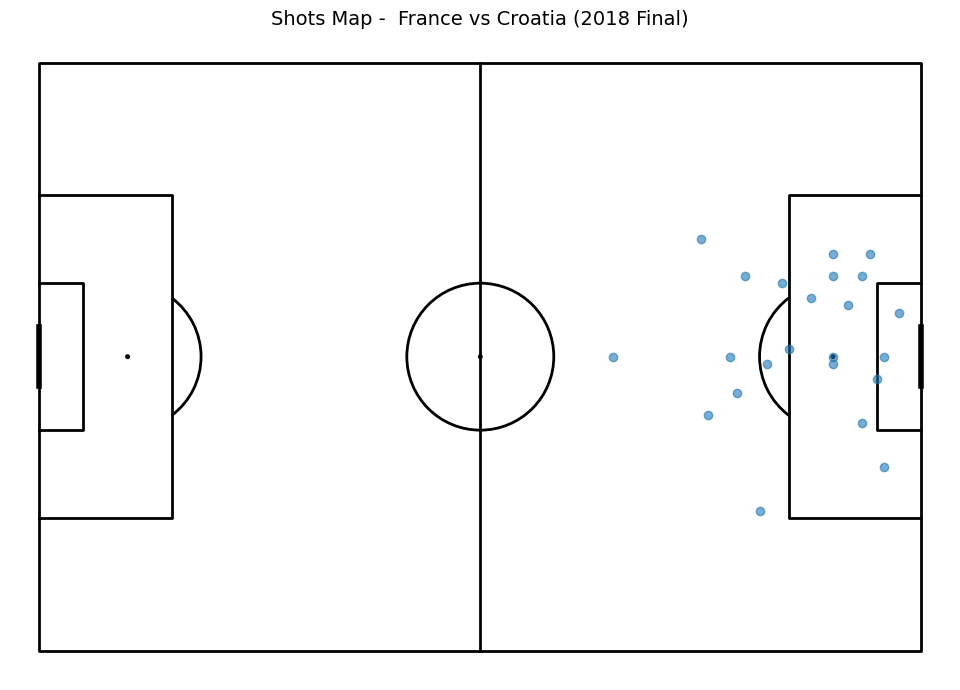

In [40]:
from mplsoccer import Pitch 

#Shotmap

pitch = Pitch(pitch_type='statsbomb',line_color='black')
fig, ax = pitch.draw(figsize=(10,7))

#Draw shots
pitch.scatter(shots['x'], shots['y'], ax=ax, alpha=0.6)
ax.set_title("Shots Map -  France vs Croatia (2018 Final)", fontsize=14)
fig.savefig("shot_map.png", dpi=300, bbox_inches='tight')
plt.show()

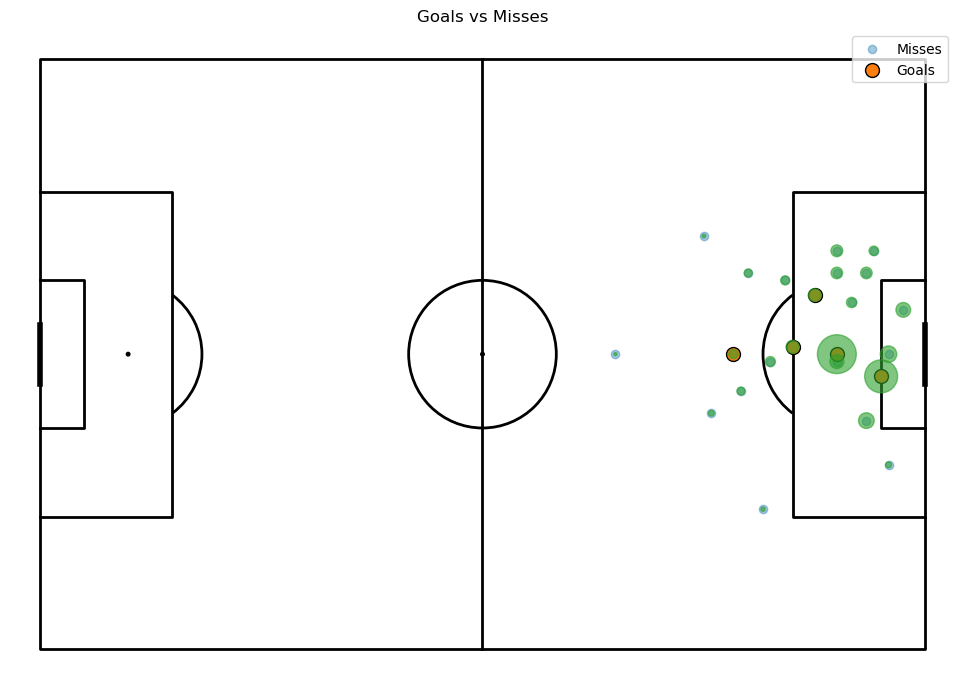

In [41]:
#Goals vs Misses 

pitch = Pitch(pitch_type='statsbomb', line_color='black')
fig, ax = pitch.draw(figsize=(10, 7))

pitch.scatter(misses['x'], misses['y'], ax=ax, alpha=0.4,label='Misses')
pitch.scatter(goals['x'], goals['y'], ax=ax, s=100, edgecolor='black', label='Goals')
ax.legend()
ax.set_title("Goals vs Misses")

pitch.scatter(
    shots['x'],
    shots['y'],
    s=shots['shot_statsbomb_xg'] * 1000,
    ax=ax,
    alpha=0.6
)
fig.savefig("goals_map.png", dpi=300, bbox_inches='tight')
plt.show()


In [42]:
shots['team'].value_counts()


Croatia    15
France      8
Name: team, dtype: int64

In [43]:
shots.groupby('team')['shot_statsbomb_xg'].sum()

team
Croatia    1.480288
France     1.097964
Name: shot_statsbomb_xg, dtype: float64

In [44]:
goals = shots[shots['shot_outcome'] == 'Goal']

goals_by_type = goals.groupby(['team', 'shot_type']).size().reset_index(name='count')

goals_by_type

,team,shot_type,count
0,Croatia,Open Play,2
1,France,Open Play,2
2,France,Penalty,1


## Player Efficiency Analysis

In [45]:
player_stats = shots.groupby('player').agg({
    'shot_outcome': lambda x: (x == 'Goal').sum(),
    'shot_statsbomb_xg': 'sum',
    'id': 'count' 
}) 

player_stats.columns = ['goals', 'xG', 'shots']
player_stats['conversion'] = player_stats['goals'] / player_stats['shots']

player_stats.sort_values('conversion', ascending=False) 
player_stats
                                           
                                           

,goals,xG,shots,conversion
player,,,,
Ante Rebić,0,0.209038,3,0.0
Antoine Griezmann,1,0.816898,2,0.5
Dejan Lovren,0,0.101757,2,0.0
Domagoj Vida,0,0.268797,2,0.0
Ivan Perišić,1,0.196192,2,0.5
Ivan Rakitić,0,0.119029,3,0.0
Kylian Mbappé Lottin,1,0.063422,2,0.5
Mario Mandžukić,1,0.563190,1,1.0
Nabil Fekir,0,0.009616,1,0.0


## Key Insights



- Despite generating fewer shots, France maximized shot quality and efficiency, which proved decisive.
- Shot quality and efficiency can outweigh shot volume.
- France’s performance reflects a more clinical and optimized attacking approach, which ultimately led to victory.
